Problem: Predict house price using housing features

Target: MedHouseVal

ML Type: Regression

In [16]:
# California Housing Price Prediction

## 1. Problem Statement
## 2. Import Libraries
## 3. Load Dataset
## 4. Exploratory Data Analysis
## 5. Correlation Analysis
## 6. Train-Test Split
## 7. Linear Regression Model
## 8. Model Evaluation
## 9. Residual Analysis
## 10. Actual vs Predicted Visualization
## 11. Conclusion

In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

# Load dataset
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["MedHouseVal"] = data.target
df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [17]:
df.shape
df.isnull().sum()
df.duplicated().sum()
print("Dataset Shape:", df.shape)
print("Missing Values:\n", df.isnull().sum())
print("Duplicate Rows:", df.duplicated().sum())

Dataset Shape: (20640, 9)
Missing Values:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64
Duplicate Rows: 0


In [3]:
df["MedHouseVal"].agg(["min", "max"])


min    0.14999
max    5.00001
Name: MedHouseVal, dtype: float64

In [4]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [5]:
df.corr()["MedHouseVal"].sort_values(ascending=False)
# Median Income has strongest correlation with house price

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

In [6]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split



In [18]:
x = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]
x_train , x_test , y_train , y_test= train_test_split (
x , y,test_size=0.2, random_state=42)
model=LinearRegression()
model.fit(x_train,y_train) 
y_pred=model.predict(x_test)



In [15]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
rmse=np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MSE: 0.5558915986952441
RMSE: 0.7455813830127762
R2 Score: 0.575787706032451


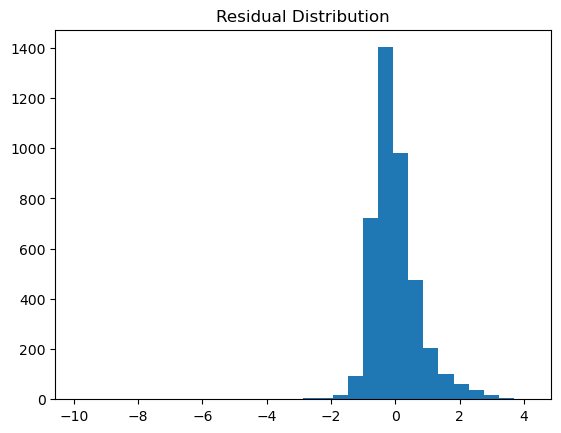

In [9]:
import matplotlib.pyplot as plt
residuals = y_test - y_pred
plt.hist(residuals, bins=30)
plt.title("Residual Distribution")
plt.show()

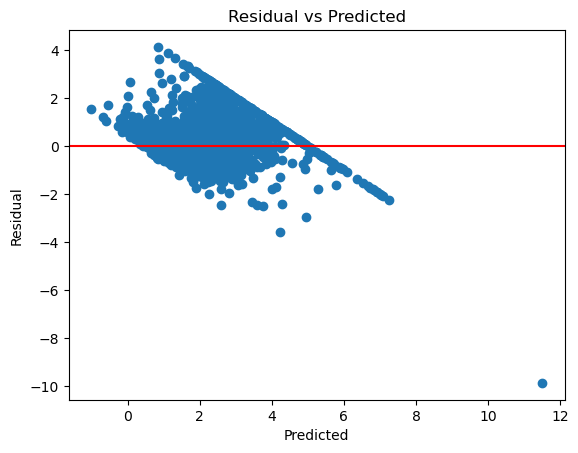

In [10]:
plt.scatter(y_pred, residuals)
plt.axhline(0, color="red")
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual vs Predicted")
plt.show()

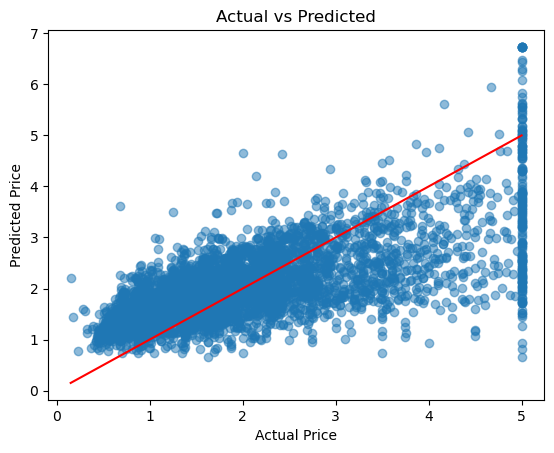

In [13]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')  # perfect line
plt.show()

## Feature Selection Experiment
Removing weak features and testing model performance.

In [21]:
selected_features = ["MedInc","AveRooms","HouseAge","Latitude","Longitude"]

X = df[selected_features]
y = df["MedHouseVal"]

x_train,x_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

model = LinearRegression()
model.fit(x_train,y_train)

y_pred = model.predict(x_test)

mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

print("R2 Score:",r2)

R2 Score: 0.5813744243302476


Feature selection slightly improved model performance 
(R² improved from ~0.57 to ~0.58).
Selected features were chosen based on correlation strength with the target variable.

Conclusion:

The baseline Linear Regression model achieved an R² score of ~0.57.

After removing weaker features, the model performance slightly improved to ~0.58.

Median Income (MedInc) was found to be the strongest predictor of housing prices.

The model struggles with higher house values due to the dataset target cap.

Future improvements could include:

• Regularization (Ridge / Lasso)
• Ensemble models
• Feature engineering